In [5]:

import ee
import geemap

ee.Initialize(project="velvety-gearbox-451304-s0")

lon_min, lat_min, lon_max, lat_max = 72.5833, 18.7833, 73.2000, 19.6000
city_bbox = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])

l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(city_bbox)
    .filterDate("2023-01-01", "2023-03-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20)))

print("Images found:", l8.size().getInfo())

image = l8.sort("CLOUD_COVER").first()
lst = image.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15).subtract(273.15)

Images found: 18


In [16]:
stats = lst.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=city_bbox,
    scale=30,
    maxPixels=1e9
)
print(stats.getInfo())

{'ST_B10_max': -225.88629699999996, 'ST_B10_min': -242.02618743999994}


In [19]:
paths = l8.aggregate_array("WRS_PATH").getInfo()
rows = l8.aggregate_array("WRS_ROW").getInfo()
print(list(zip(paths, rows)))

[(147, 46), (147, 46), (147, 46), (147, 46), (147, 47), (147, 47), (147, 47), (147, 47), (147, 47), (148, 46), (148, 46), (148, 46), (148, 46), (148, 47), (148, 47), (148, 47), (148, 47), (148, 47)]


In [21]:
def mask_l8_clouds(image):
    qa = image.select("QA_PIXEL")
    cloud_shadow_bit = 1 << 4
    cloud_bit = 1 << 3
    mask = qa.bitwiseAnd(cloud_shadow_bit).eq(0).And(qa.bitwiseAnd(cloud_bit).eq(0))
    return image.updateMask(mask)

l8_masked = l8.map(mask_l8_clouds).sort("CLOUD_COVER")  # least cloudy first
mosaic_image = l8_masked.mosaic()  # fills gaps using next-cleanest image where the first has no data

lst = mosaic_image.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15)
lst = lst.clip(city_bbox)

# Representative date for ERA5 matching later — use the least-cloudy contributing image's date
rep_date = ee.Date(l8_masked.first().get("system:time_start")).format("YYYY-MM-dd'T'HH:mm:ss").getInfo()
print("Representative scene date:", rep_date)

Map = geemap.Map(center=[19.0, 72.9], zoom=9)
Map.addLayer(city_bbox, {}, "Bounding box")
Map.addLayer(lst, {"min": 20, "max": 45, "palette": ["blue", "yellow", "red"]}, "LST")
Map

Representative scene date: 2023-02-09T05:27:45


Map(center=[19.0, 72.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [22]:
import os
print(os.getcwd())

C:\Users\vishw\urban-heat-project


In [24]:
import os
print(os.getcwd())

C:\Users\vishw\urban-heat-project


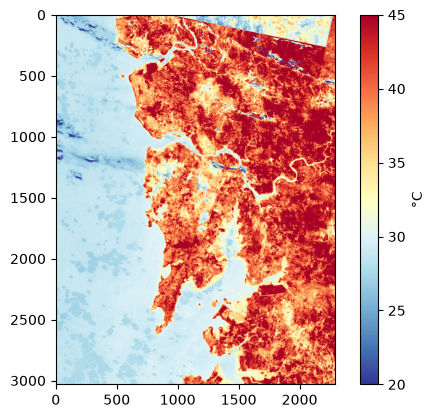

In [25]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("data/raw/lst_LANDSAT/mumbai_LST_2023_Q1.tif") as src:
    data = src.read(1)

plt.imshow(data, cmap="RdYlBu_r", vmin=20, vmax=45)
plt.colorbar(label="°C")
plt.show()

In [28]:
import rasterio
import numpy as np

with rasterio.open("data/raw/lst_LANDSAT/mumbai_LST_2023_Q1.tif") as src:
    print(src.bounds, src.crs, src.res)
    data = src.read(1)
    print("Min/Max temp:", np.nanmin(data), np.nanmax(data))

BoundingBox(left=72.58324613615846, bottom=18.783233601768725, right=73.20011924176335, top=19.60034118420384) EPSG:4326 (0.00026949458523585647, 0.00026949458523585647)
Min/Max temp: -17.709439179999976 71.09413844000005


In [29]:
total_pixels = data.size
nan_pixels = np.isnan(data).sum()
print(f"Masked (no-data) pixels: {nan_pixels} of {total_pixels} ({100*nan_pixels/total_pixels:.1f}%)")

Masked (no-data) pixels: 1400 of 6940248 (0.0%)


In [18]:
image = l8.sort("CLOUD_COVER").first()

# Mask out cloud and cloud-shadow pixels using the QA_PIXEL band
qa = image.select("QA_PIXEL")
cloud_shadow_bit = 1 << 4
cloud_bit = 1 << 3
cloud_mask = qa.bitwiseAnd(cloud_shadow_bit).eq(0).And(qa.bitwiseAnd(cloud_bit).eq(0))
image = image.updateMask(cloud_mask)

lst = image.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15)
lst = lst.clip(city_bbox)

Map = geemap.Map(center=[19.0, 72.9], zoom=9)
Map.addLayer(city_bbox, {}, "Bounding box")
Map.addLayer(lst, {"min": 20, "max": 45, "palette": ["blue", "yellow", "red"]}, "LST")
Map

Map(center=[19.0, 72.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [15]:
Map = geemap.Map(center=[19.0, 72.9], zoom=9)
Map.addLayer(city_bbox, {}, "Bounding box")
Map.addLayer(lst, {"min": 20, "max": 45, "palette": ["blue", "yellow", "red"]}, "LST")
Map

Map(center=[19.0, 72.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …